# Ch3. Time Series Decomposition
**Forecasting: Principles & Practice (Python Edition)**  
Lab Notebook · [github.com/bcseong2/fpppy-labs](https://github.com/bcseong2/fpppy-labs)

In [1]:
%pip install statsforecast neuralforecast hierarchicalforecast mlforecast utilsforecast


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## [Slide 5] 3.1 Choosing  with the Guerrero Method

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

# Guerrero method implemented in corecasts / statsmodels
from statsmodels.tsa.statespace.tools import (
    constrain_statespace_params)

# Or using scipy + grid search
from scipy.stats import boxcox
from scipy.special import inv_boxcox

# Apply Box-Cox and find optimal lambda
y = np.array([...])   # your series
y_transformed, lam = boxcox(y)
print(f"Optimal lambda: {lam:.3f}")

# Back-transform
y_back = inv_boxcox(y_transformed, lam)

ImportError: cannot import name 'constrain_statespace_params' from 'statsmodels.tsa.statespace.tools' (/Data2/data/jc25/forecast/fpppy-labs/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/tools.py)

In [3]:
from coreforecast.scalers import boxcox, boxcox_lambda

lam = boxcox_lambda(y, method="guerrero", season_length=12)
w   = boxcox(y, lam)

NameError: name 'y' is not defined

## [Slide 9] 3.3 Moving Averages

In [4]:
import pandas as pd

# 5-MA (k=2, m=5)
df["T_hat"] = df["y"].rolling(window=5, center=True).mean()

# 7-MA (for weekly data)
df["T_hat_7"] = df["y"].rolling(window=7, center=True).mean()

NameError: name 'df' is not defined

## [Slide 12] 3.3 Moving Average Visualisation

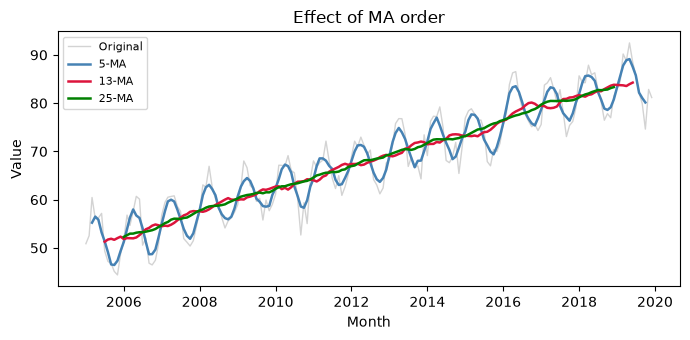

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

np.random.seed(5)
dates = pd.date_range("2005-01", periods=180, freq="MS")
y = (50 + 0.2*np.arange(180)
     + 6*np.sin(2*np.pi*np.arange(180)/12)
     + np.random.randn(180)*2)
s = pd.Series(y, index=dates)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(s, lw=1, color="lightgray", label="Original")
for m, col in [(5, "steelblue"), (13, "crimson"), (25, "green")]:
    ax.plot(s.rolling(m, center=True).mean(),
            lw=1.8, label=f"{m}-MA", color=col)
ax.legend(fontsize=8); ax.set(xlabel="Month", ylabel="Value",
                               title="Effect of MA order")
plt.tight_layout(); plt.show()

## [Slide 15] 3.4 Classical Decomposition in Python

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Additive decomposition (period=12 for monthly data)
result = seasonal_decompose(
    y_series,               # pd.Series with DatetimeIndex
    model="additive",
    period=12,
    extrapolate_trend="freq",  # avoids NaN at endpoints
)

fig = result.plot()
fig.set_size_inches(7, 5)
plt.tight_layout(); plt.show()

# Access components
trend    = result.trend
seasonal = result.seasonal
resid    = result.resid

NameError: name 'y_series' is not defined

## [Slide 21] 3.6 STL in Python (statsmodels)

In [7]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

# Fit STL (monthly data, period=12)
stl = STL(
    y_series,          # pd.Series with DatetimeIndex
    period=12,
    seasonal=13,       # odd; larger = smoother seasonal
    robust=True,       # downweight outliers
)
result = stl.fit()

# Plot all four components
fig = result.plot()
fig.set_size_inches(7, 5)
plt.tight_layout(); plt.show()

# Extract components
trend    = result.trend
seasonal = result.seasonal
resid    = result.resid

NameError: name 'y_series' is not defined

## [Slide 23] 3.6 STL Decomposition --- Worked Example

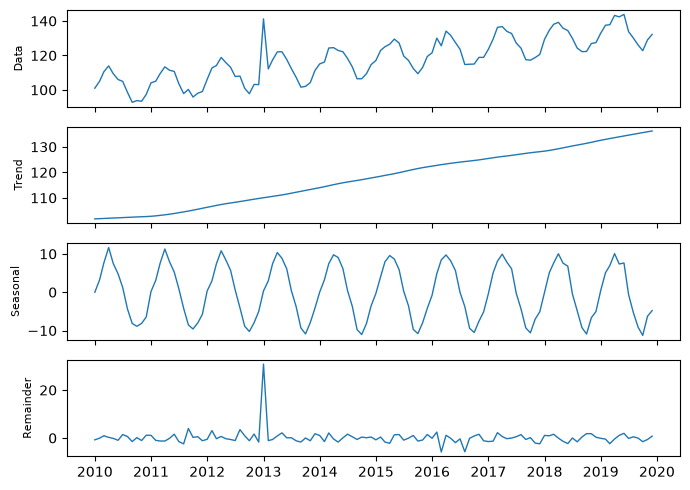

In [8]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

np.random.seed(42)
n = 120
dates = pd.date_range("2010-01", periods=n, freq="MS")
trend_true = 100 + 0.3*np.arange(n)
seasonal_true = 10*np.sin(2*np.pi*np.arange(n)/12)
noise = np.random.randn(n)*2
# Introduce an outlier
y = trend_true + seasonal_true + noise
y[36] += 30

s = pd.Series(y, index=dates)
stl = STL(s, period=12, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(7, 5), sharex=True)
for ax, comp, lbl in zip(axes,
        [s, res.trend, res.seasonal, res.resid],
        ["Data", "Trend", "Seasonal", "Remainder"]):
    ax.plot(comp, lw=1); ax.set_ylabel(lbl, fontsize=8)
plt.tight_layout(); plt.show()

## [Slide 25] 3.7 MSTL: Multiple Seasonal Decomposition

In [9]:
from statsmodels.tsa.seasonal import MSTL

# Half-hourly series with daily + weekly patterns
mstl = MSTL(
    elec_series,
    periods=(48, 336),    # daily and weekly
)
result = mstl.fit()

# result.seasonal is a DataFrame with one column per period
print(result.seasonal.head())

NameError: name 'elec_series' is not defined

## [Slide 27] 3.7 MSTL Visualisation

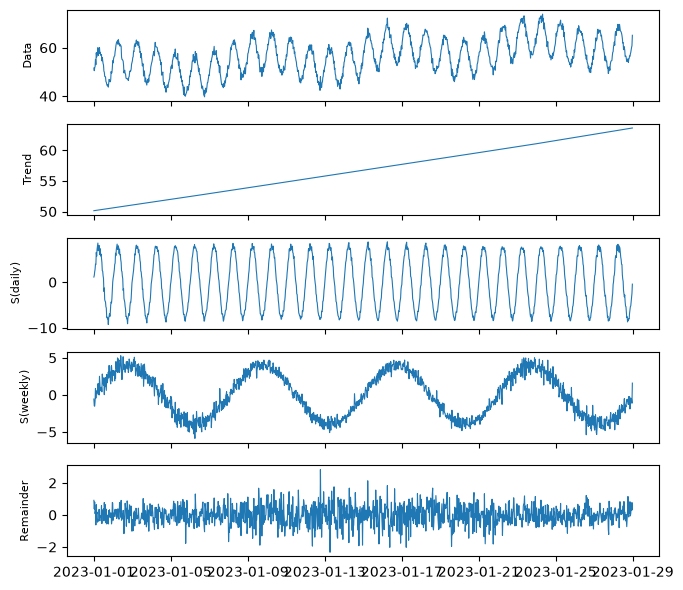

In [10]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL
import pandas as pd, numpy as np

# Simulate half-hourly series (1 week = 336 obs)
np.random.seed(1)
t = np.arange(336*4)
y = (50 + 0.01*t
     + 8*np.sin(2*np.pi*t/48)          # daily
     + 4*np.sin(2*np.pi*t/336)         # weekly
     + np.random.randn(len(t)))
s = pd.Series(y,
      index=pd.date_range("2023-01-01", periods=len(t), freq="30min"))

res = MSTL(s, periods=(48, 336)).fit()
fig, axes = plt.subplots(5, 1, figsize=(7, 6), sharex=True)
for ax, (lbl, comp) in zip(axes, {
        "Data": s, "Trend": res.trend,
        "S(daily)": res.seasonal.iloc[:,0],
        "S(weekly)": res.seasonal.iloc[:,1],
        "Remainder": res.resid}.items()):
    ax.plot(comp, lw=0.8); ax.set_ylabel(lbl, fontsize=8)
plt.tight_layout(); plt.show()

## [Slide 30] 3.8 Computing Trend/Seasonality Strength

In [11]:
import numpy as np
from statsmodels.tsa.seasonal import STL

def trend_strength(series, period=12, robust=True):
    res = STL(series, period=period, robust=robust).fit()
    var_R   = np.var(res.resid)
    var_TR  = np.var(res.trend + res.resid)
    return max(0, 1 - var_R / var_TR)

def season_strength(series, period=12, robust=True):
    res = STL(series, period=period, robust=robust).fit()
    var_R   = np.var(res.resid)
    var_SR  = np.var(res.seasonal + res.resid)
    return max(0, 1 - var_R / var_SR)

Ft = trend_strength(s, period=12)
Fs = season_strength(s, period=12)
print(f"F_T = {Ft:.3f},  F_S = {Fs:.3f}")

F_T = 0.966,  F_S = 0.106


## [Slide 33] 3.10 Full Decomposition Pipeline

In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy.special import inv_boxcox
from scipy.stats import boxcox

# 1. Load data
y = pd.read_csv("data/retail.csv",
                parse_dates=["Month"], index_col="Month")["Sales"]

# 2. Box-Cox transformation (stabilise variance)
y_bc, lam = boxcox(y)
y_s = pd.Series(y_bc, index=y.index)

# 3. STL decomposition on transformed series
stl = STL(y_s, period=12, robust=True)
res = stl.fit()

# 4. Seasonally adjusted (on original scale)
sa_bc = y_bc - res.seasonal
sa    = inv_boxcox(sa_bc, lam)

# 5. Trend strength
Ft = max(0, 1 - np.var(res.resid)/np.var(res.trend + res.resid))
print(f"Trend strength F_T = {Ft:.3f}")

FileNotFoundError: [Errno 2] No such file or directory: 'data/retail.csv'